# SV climate-purging: temperature (bio1) vs aridity (bio18), and the overall-purging confound

β = d(s)/d(climate) per variant (removes the constant hitchhiking offset + p₀ artifact). Two climate
axes: **bio1** = mean annual temperature, **bio18** = precipitation of the warmest quarter (low = arid
summer — the strongest single correlate). Plus a plot of **overall purging intensity vs climate** to
show the general effect and how the SV excess rides on top of it.

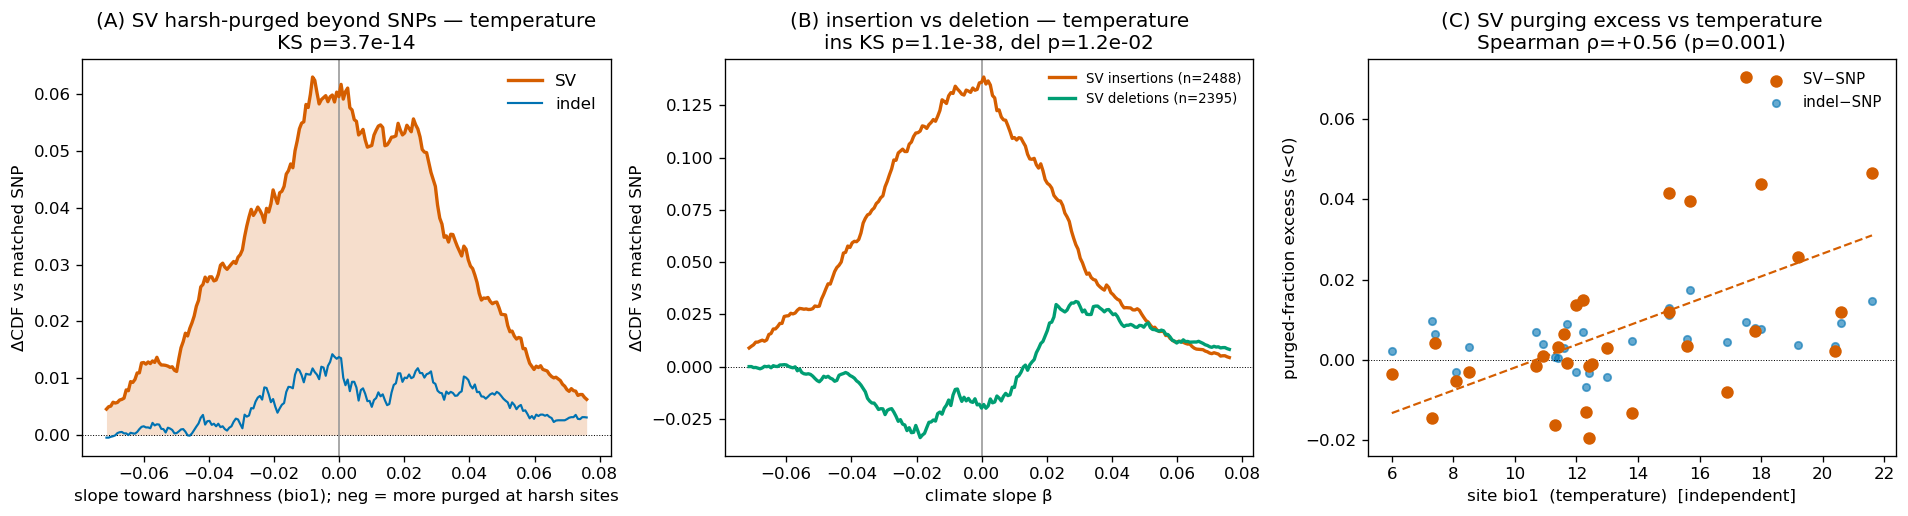

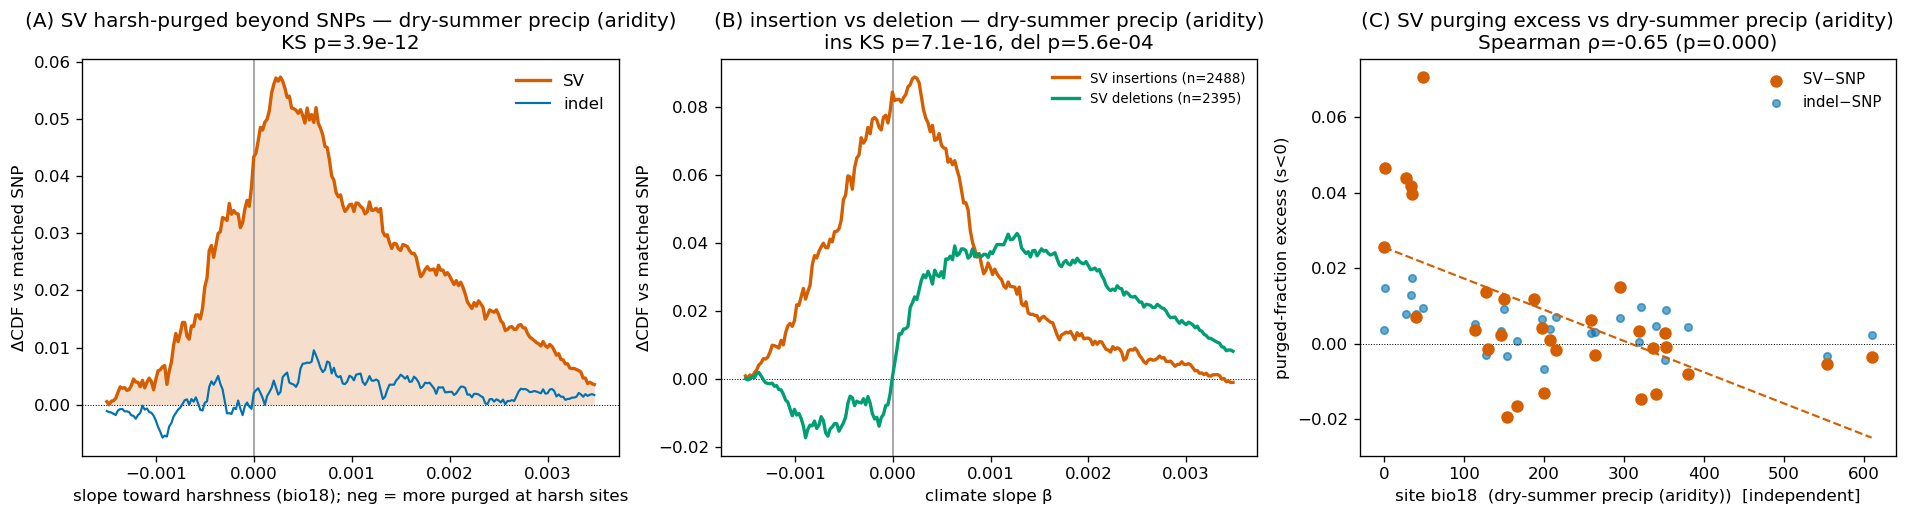

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G="/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/s_climate_slope.npz"); sign=pd.read_csv(f"{G}/s_climate_slope_sign_by_site.csv")
COL={"SNP":"#888888","indel":"#0072B2","SV":"#D55E00","ins":"#D55E00","del":"#009E73"}
NBIN,NDRAW=25,20000; rng=np.random.default_rng(0)
def match_to(tp0,ss,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,NBIN+1)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for b in range(NBIN):
        k=int(round((tb==b).mean()*NDRAW)); pool=ss[sb==b]
        if k>0 and pool.size: out.append(rng.choice(pool,k,replace=True))
    return np.concatenate(out)
GRID=np.linspace(-0.008,0.006,220) if False else None

def make(cvar, label, sign_sign):
    # flip sign so NEGATIVE always = more purged at HARSH sites (bio1: hot=high; bio18: arid=low precip)
    bsv=sign_sign*z[f"beta_sv_{cvar}"]; bind=sign_sign*z[f"beta_indel_{cvar}"]; bsn=sign_sign*z[f"beta_snp_{cvar}"]
    msnp=match_to(z["p0_sv"],bsn,z["p0_snp"]); mind=match_to(z["p0_sv"],bind,z["p0_indel"])
    lo,hi=np.percentile(np.concatenate([bsv,msnp]),[1,99]); grid=np.linspace(lo,hi,220)
    cdf=lambda s:(np.searchsorted(np.sort(s),grid,side="right")/s.size)
    base=cdf(msnp)
    fig,ax=plt.subplots(1,3,figsize=(16,4.4))
    ax[0].axhline(0,color="k",lw=.6,ls=":"); ax[0].axvline(0,color="0.6",lw=1)
    ax[0].fill_between(grid,0,cdf(bsv)-base,color=COL["SV"],alpha=.2,lw=0)
    ax[0].plot(grid,cdf(bsv)-base,color=COL["SV"],lw=2,label="SV")
    ax[0].plot(grid,cdf(mind)-base,color=COL["indel"],lw=1.3,label="indel")
    ax[0].set_xlabel(f"slope toward harshness ({cvar}); neg = more purged at harsh sites"); ax[0].set_ylabel("ΔCDF vs matched SNP")
    ax[0].set_title(f"(A) SV harsh-purged beyond SNPs — {label}\nKS p={stats.ks_2samp(bsv,msnp).pvalue:.1e}")
    ax[0].legend(frameon=False)
    ins=bsv[~z["sv_isdel"]]; dele=bsv[z["sv_isdel"]]
    ax[1].axhline(0,color="k",lw=.6,ls=":"); ax[1].axvline(0,color="0.6",lw=1)
    ax[1].plot(grid,cdf(ins)-base,color=COL["ins"],lw=2,label=f"SV insertions (n={ins.size})")
    ax[1].plot(grid,cdf(dele)-base,color=COL["del"],lw=2,label=f"SV deletions (n={dele.size})")
    ax[1].set_xlabel(f"climate slope β"); ax[1].set_ylabel("ΔCDF vs matched SNP")
    ax[1].set_title(f"(B) insertion vs deletion — {label}\nins KS p={stats.ks_2samp(ins,msnp).pvalue:.1e}, del p={stats.ks_2samp(dele,msnp).pvalue:.1e}")
    ax[1].legend(frameon=False,fontsize=8)
    d=sign.copy(); d["excess"]=d.sv_neg-d.msnp_neg
    r=stats.spearmanr(d[cvar],d.excess)
    ax[2].axhline(0,color="k",lw=.6,ls=":")
    ax[2].scatter(d[cvar],d.excess,c=COL["SV"],s=42,zorder=3,label="SV−SNP")
    ax[2].scatter(d[cvar],d.mindel_neg-d.msnp_neg,c=COL["indel"],s=20,alpha=.6,label="indel−SNP")
    b,a0=np.polyfit(d[cvar],d.excess,1); xs=np.array([d[cvar].min(),d[cvar].max()])
    ax[2].plot(xs,a0+b*xs,color=COL["SV"],ls="--",lw=1.3)
    ax[2].set_xlabel(f"site {cvar}  ({label})  [independent]"); ax[2].set_ylabel("purged-fraction excess (s<0)")
    ax[2].set_title(f"(C) SV purging excess vs {label}\nSpearman ρ={r.statistic:+.2f} (p={r.pvalue:.3f})")
    ax[2].legend(frameon=False,fontsize=9)
    fig.tight_layout(); fig.savefig(f"{G}/s_climate_slope_{cvar}.png",dpi=130,bbox_inches="tight"); plt.show()

make("bio1","temperature",+1)
make("bio18","dry-summer precip (aridity)",-1)


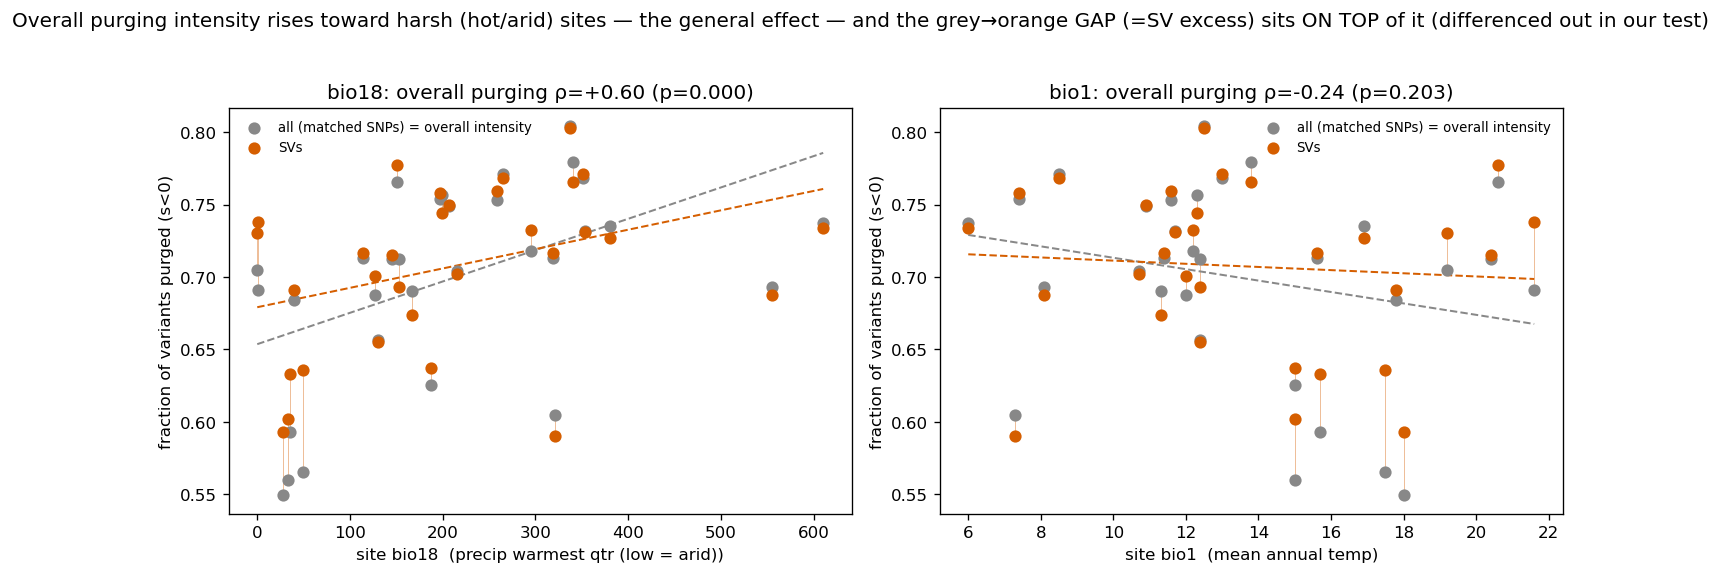

overall intensity (matched SNP purged frac): range 0.55-0.80
corr(intensity, bio18)=+0.60  corr(intensity, bio1)=-0.24


In [2]:

# OVERALL PURGING INTENSITY vs climate, with SV overlaid — addresses the confound visually
d=sign.copy()
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
for a,(cv,lab) in zip(ax,[("bio18","precip warmest qtr (low = arid)"),("bio1","mean annual temp")]):
    a.scatter(d[cv],d.msnp_neg,c="#888888",s=40,zorder=3,label="all (matched SNPs) = overall intensity")
    a.scatter(d[cv],d.sv_neg,c="#D55E00",s=40,zorder=3,label="SVs")
    for x,lo,hi in zip(d[cv],d.msnp_neg,d.sv_neg):
        a.plot([x,x],[lo,hi],color="#D55E00",lw=0.6,alpha=0.4,zorder=2)  # gap = SV excess
    for cc,col in [("msnp_neg","#888888"),("sv_neg","#D55E00")]:
        b,a0=np.polyfit(d[cv],d[cc],1); xs=np.array([d[cv].min(),d[cv].max()]); a.plot(xs,a0+b*xs,color=col,ls="--",lw=1.2)
    r=stats.spearmanr(d[cv],d.msnp_neg)
    a.set_xlabel(f"site {cv}  ({lab})"); a.set_ylabel("fraction of variants purged (s<0)")
    a.set_title(f"{cv}: overall purging ρ={r.statistic:+.2f} (p={r.pvalue:.3f})")
    a.legend(frameon=False,fontsize=8)
fig.suptitle("Overall purging intensity rises toward harsh (hot/arid) sites — the general effect — "
             "and the grey→orange GAP (=SV excess) sits ON TOP of it (differenced out in our test)", y=1.03)
fig.tight_layout(); fig.savefig(f"{G}/s_purging_intensity.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"overall intensity (matched SNP purged frac): range {d.msnp_neg.min():.2f}-{d.msnp_neg.max():.2f}")
print(f"corr(intensity, bio18)={stats.spearmanr(d.bio18,d.msnp_neg).statistic:+.2f}  "
      f"corr(intensity, bio1)={stats.spearmanr(d.bio1,d.msnp_neg).statistic:+.2f}")


### Reading
- **bio1 and bio18 figures**: the SV climate-purging hump (A) and the insertion-only split (B) hold on
  *both* axes; the sign view (C) shows the excess grows toward hot **and** arid. Aridity (bio18) is the
  stronger correlate.
- **Overall-purging plot**: grey (all/matched-SNP) rises toward harsh sites — the general "everything
  gets purged more" effect you flagged is real (ρ≈+0.6). But the **grey→orange gap** (the SV excess) is
  a *within-site* difference that our test isolates, and it is *not* produced by the overall rise (the
  gap doesn't scale with intensity; only insertions show it). So the general effect is present but does
  not explain the SV/insertion signal.